# Heart Disease Project: Cleveland Dataset Analysis

---

## Project Goals

This project explores the Cleveland Heart Disease dataset to prepare it for machine learning analysis. The goals of this analysis are:

1. **Clean and preprocess** the dataset to ensure it's usable for further analysis and modeling.
2. **Identify key features** that are most associated with the presence of heart disease.
3. **Compare trends between patients with and without heart disease** using descriptive statistics and visual tools.
4. **Use statistical tests and Python-based tools** to evaluate whether observed differences are significant.

---
## Introduction

This project utilizes the Cleveland Heart Disease dataset from the University of California Irvine (UCI) Machine Learning Repository. The dataset was created with the intent of helping researchers and clinicians better understand the various clinical features associated with heart disease. Specifically, this analysis aims to uncover key predictors and their relative importance in predicting the presence of heart disease, and further validate these findings using additional datasets from VA, Hungary, and Switzerland.

The Cleveland dataset contains clinical and diagnostic measurements for 303 patients, including attributes such as age, sex, chest pain type (cp), resting blood pressure (trestbps), cholesterol level (chol), fasting blood sugar (fbs), resting electrocardiogram results (restecg), maximum heart rate achieved (thalach), exercise-induced angina (exang), ST depression induced by exercise (oldpeak), slope of the peak exercise ST segment (slope), number of major vessels colored by fluoroscopy (ca), and results from the Thallium stress test (thal).

**The broader goal of this analysis is to enhance our understanding of which clinical features most strongly correlate with heart disease, and how consistently these findings apply to different populations.**

While the Cleveland dataset itself is relatively small, it can still be valueable in exploring features that are correlated with heart disease. To robustly test the findings from Cleveland, I incorporated additional datasets from VA (294 patients), Hungary (123 patients), and Switzerland (200 patients). These datasets provide comparative perspectives and help validate whether patterns observed in Cleveland are broadly applicable or location-specific.

However, there are some important limitations and considerations:

1. **Missing and Inconsistent Data**: The datasets contain some missing or incorrectly recorded values, requiring careful preprocessing and cleaning.
2. **Population Differences**: Each dataset represents distinct geographic and demographic patient populations, potentially introducing variability in clinical outcomes.
3. **Limited Feature Set**: While extensive, the feature set does not include some potentially relevant clinical information such as detailed family medical history, lifestyle habits, or precise medication data.

This project first aims to thoroughly clean and preprocess the datasets, followed by a comprehensive exploratory analysis utilizing statistical methods and visualization techniques learned in this course (such as pandas, NumPy, seaborn, and matplotlib). Subsequently, the project seeks to identify and validate significant predictors of heart disease and evaluate the consistency of these predictors across different populations. Insights gained from this analysis have the potential to inform future clinical research and patient management strategies.

---

## Contents
1. Imports and Setup
2. Load and Clean the Dataset
    - Explanation of Variables
    - Check and Fill Missing Values
    - Outlier Detection and Treatment (IQR method)
4. Custom Utility Function
5. Descriptive Analysis – Numeric Features
    - Numeric means and basic comparisons
    - Boxplots
6. Descriptive Analysis – Categorical Features
    - Basic proportion analysis
    - Categorical Feature Encoding and Frequency Analysis
7. Custom Risk Classification Based on Feature Interactions
    - Manual Threshold Classifier
    - Heatmap-based interaction
8. Rule-Based Risk Prediction Accuracy
9. Feature Interaction Analysis
11. Additional Dataset Loading and Comparison (VA, Hungary, Switzerland)
    - Basic stats
    - Comparative Analysis Across Locations
8. Final Summary and Conclusions

---

## 1. Imports and Setup

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

---

## 2. Load and Clean the Dataset

In [8]:
df = pd.read_csv('processed.cleveland.data')
df.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


### Explanation of Variables

- **age**: Age of the patient in years.
- **sex**: Gender of the patient (1 = male, 0 = female).
- **cp**: Chest pain type (values 0–3):
  - 0: Typical angina
  - 1: Atypical angina
  - 2: Non-anginal pain
  - 3: Asymptomatic
- **trestbps**: Resting blood pressure (in mm Hg on admission).
- **chol**: Serum cholesterol in mg/dl.
- **fbs**: Fasting blood sugar (> 120 mg/dl) (1 = true; 0 = false).
- **restecg**: Resting electrocardiographic results (values 0–2):
  - 0: Normal
  - 1: ST-T wave abnormality
  - 2: Left ventricular hypertrophy
- **thalach**: Maximum heart rate achieved.
- **exang**: Exercise-induced angina (1 = yes; 0 = no).
- **oldpeak**: ST depression induced by exercise relative to rest.
- **slope**: The slope of the peak exercise ST segment:
  - 0: Upsloping
  - 1: Flat
  - 2: Downsloping
- **ca**: Number of major vessels (0–3) colored by fluoroscopy.
- **thal**: Thalassemia (values 1–3):
  - 3: Normal
  - 6: Fixed defect
  - 7: Reversible defect
- **target**: Presence of heart disease (0 = no presence, 1 = presence)

**Rename columns:**

In [11]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]
df = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


**Check for missing values**

In [14]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

**Fill missing values in 'ca' and 'thal'**
- Use median for 'ca'
- Use mode for 'thal'

In [17]:
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

In [19]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

**Create binary target column**
- 0 = no disease
- 1 = has disease (target > 0)

In [22]:
df['has_disease'] = (df['target'] > 0).astype(int)

### Outlier Detection and Treatment using IQR
- Based on the Interquartile Range (IQR). Data points below Q1 - 1.5×IQR or above Q3 + 1.5×IQR are considered outliers

In [25]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [27]:
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    lower_outliers = df[col] < lower_bound
    upper_outliers = df[col] > upper_bound
    
    total_outliers = lower_outliers.sum() + upper_outliers.sum()
    print(f"{col} - Outliers: {total_outliers}")

age - Outliers: 0
trestbps - Outliers: 9
chol - Outliers: 5
thalach - Outliers: 1
oldpeak - Outliers: 5


In [29]:
outlier_mask = pd.DataFrame(False, index=df.index, columns=numeric_cols)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

df_no_outliers = df[~outlier_mask.any(axis=1)]

print(f"Total rows removed due to outliers: {df.shape[0] - df_no_outliers.shape[0]}")
df = df_no_outliers.copy()

Total rows removed due to outliers: 19


---

## 3. Custom Utility Functions

In [32]:
def group_means(df, group_col, cols):
    """
    Returns the mean of selected columns grouped by a target column.
    """
    return df.groupby(group_col)[cols].mean()

In [34]:
def compute_diff(df, col):
    """
    Computes the difference in mean for a column between patients with and without heart disease.
    """
    return df[df['has_disease'] == 1][col].mean() - df[df['has_disease'] == 0][col].mean()

In [36]:
def count_above_mean(series):
    """
    Counts how many values in a numeric Series are above its mean.
    """
    mean_val = np.mean(series)
    return np.sum(series > mean_val)

In [72]:
def proportion_table(df, group_col, target_col):
    """
    Returns a normalized value count table for categorical comparisons.
    """
    return df.groupby(group_col)[target_col].value_counts(normalize=True)

---

## 4. Descriptive Analysis – Numeric Features

**Mean Values by Disease Status**

In [76]:
print(group_means(df, 'has_disease', numeric_cols))

                   age    trestbps        chol     thalach   oldpeak
has_disease                                                         
0            52.246835  128.303797  238.126582  158.474684  0.556329
1            56.357143  132.087302  248.063492  139.373016  1.440476


In [78]:
above_mean_counts = {col: count_above_mean(df[col]) for col in numeric_cols}
pd.DataFrame.from_dict(above_mean_counts, orient='index', columns=['Count Above Mean'])

,Count Above Mean
age,144
trestbps,152
chol,136
thalach,156
oldpeak,123


**Difference in mean values for each numeric feature**
- Positive differences: Higher average values in patients with heart disease.
- Negative differences: Higher average values in patients without heart disease.

In [81]:
for col in numeric_cols:
    diff = compute_diff(df, col)
    if diff > 0:
        print(f"{col}:(+{diff:.2f})")
    else:
        print(f"{col}:({diff:.2f})")

age:(+4.11)
trestbps:(+3.78)
chol:(+9.94)
thalach:(-19.10)
oldpeak:(+0.88)


Age, Resting Blood Pressure (trestbps), Cholesterol (chol), and ST Depression (oldpeak) are higher, on average, among patients with heart disease. However, Maximum Heart Rate (thalach) is notably higher among patients without heart disease. This shows that older age, elevated blood pressure, higher cholesterol, increased ST depression, and lower maximum heart rate during exercise are important indicators associated with heart disease presence.

### Boxplots for Numeric Features

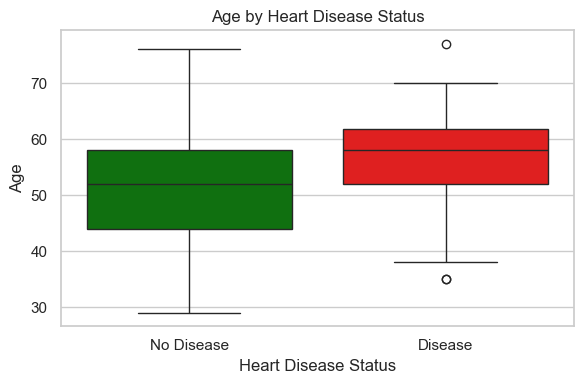

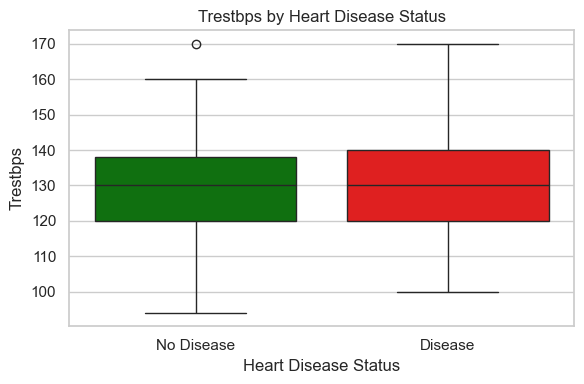

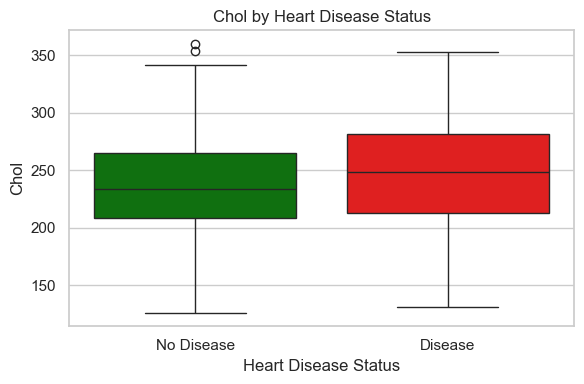

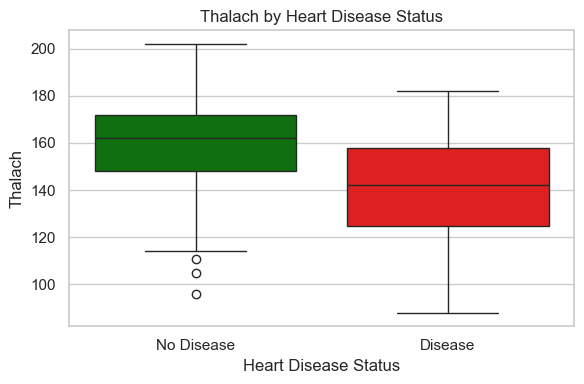

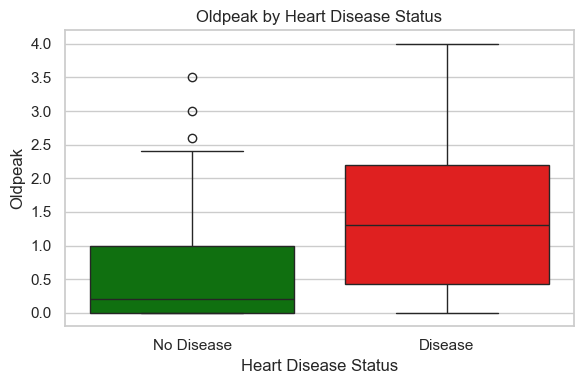

In [85]:
df['disease_str'] = df['has_disease'].map({0: 'No Disease', 1: 'Disease'})
colors = {'No Disease': 'green', 'Disease': 'red'}

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='disease_str', y=col, hue='disease_str', data=df, palette=colors, dodge=False)
    plt.title(f'{col.capitalize()} by Heart Disease Status')
    plt.xlabel('Heart Disease Status')
    plt.ylabel(col.capitalize())
    plt.tight_layout()
    plt.show()

These boxplots compare the distribution of numeric health features between patients with and without heart disease:
- **Age**: Patients with heart disease tend to be older. The median age is higher, and the entire distribution shifts upward compared to those without the disease.
- **Resting Blood Pressure (trestbps)**: There's a small upward shift in blood pressure among those with heart disease, but the difference is modest. The overlap between groups suggests it may not be a strong standalone predictor.
- **Cholesterol (chol)**: Cholesterol levels are slightly higher in the disease group, with a similar range but a higher median. However, the wide spread and overlap indicate it's not a significant factor.
- **Maximum Heart Rate Achieved (thalach)**: Patients without heart disease have significantly higher maximum heart rates. A lower thalach appears to be strongly associated with heart disease.
- **ST Depression (oldpeak)**: A much higher median and a wider spread in the disease group show that patients with heart disease have much higher ST depression values
The strongest differences are seen in thalach and oldpeak, which show clear separation between the groups. Age is also meaningfully different. Trestbps and chol show smaller shifts and greater overlap, suggesting they may still matter — but likely in combination with other features.

---

## 5. Descriptive Analysis – Categorical Features


### Barplots

In [60]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

**Proportion of heart disease status by each categorical feature**

In [92]:
for col in categorical_cols:
    print(f"\n{col.upper()} vs Heart Disease:")
    print(proportion_table(df, col, 'has_disease'))


SEX vs Heart Disease:
sex  has_disease
0.0  0              0.790698
     1              0.209302
1.0  1              0.545455
     0              0.454545
Name: proportion, dtype: float64

CP vs Heart Disease:
cp   has_disease
1.0  0              0.681818
     1              0.318182
2.0  0              0.836735
     1              0.163265
3.0  0              0.792683
     1              0.207317
4.0  1              0.717557
     0              0.282443
Name: proportion, dtype: float64

FBS vs Heart Disease:
fbs  has_disease
0.0  0              0.561475
     1              0.438525
1.0  0              0.525000
     1              0.475000
Name: proportion, dtype: float64

RESTECG vs Heart Disease:
restecg  has_disease
0.0      0              0.645833
         1              0.354167
1.0      0              0.500000
         1              0.500000
2.0      1              0.536232
         0              0.463768
Name: proportion, dtype: float64

EXANG vs Heart Disease:
exang  has_dis

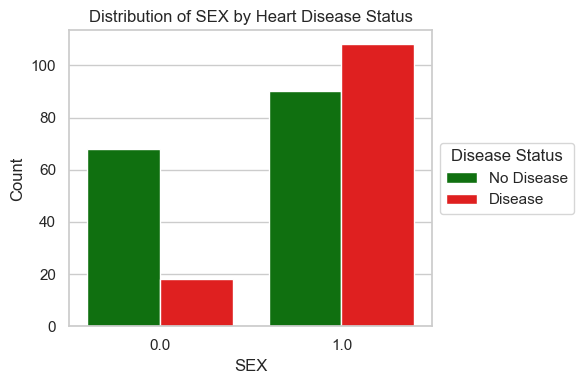

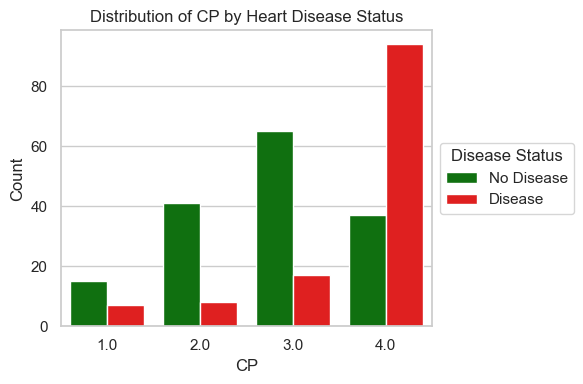

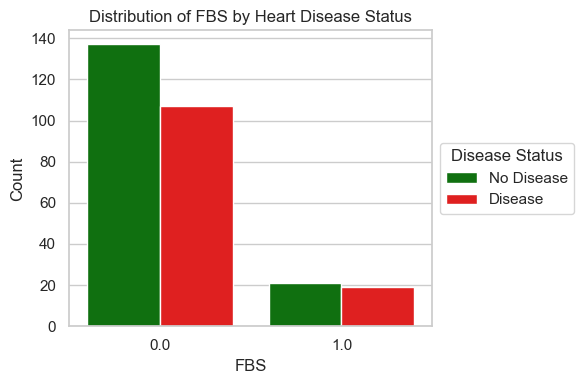

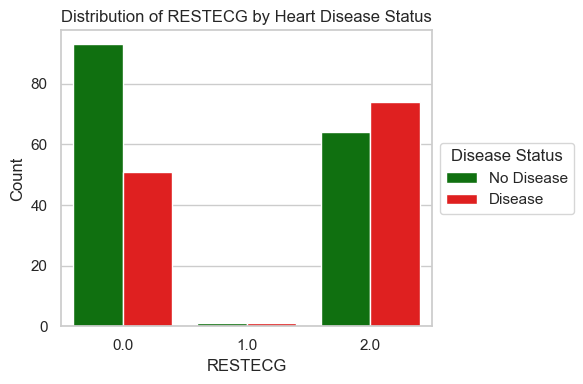

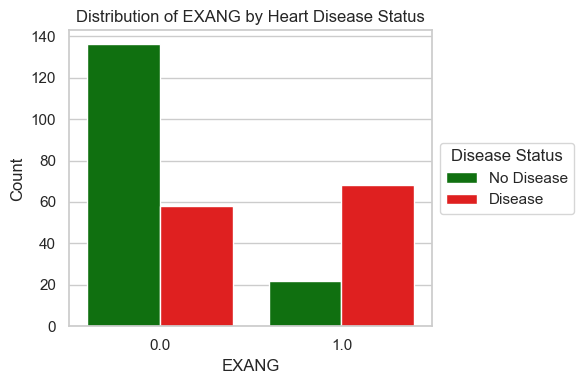

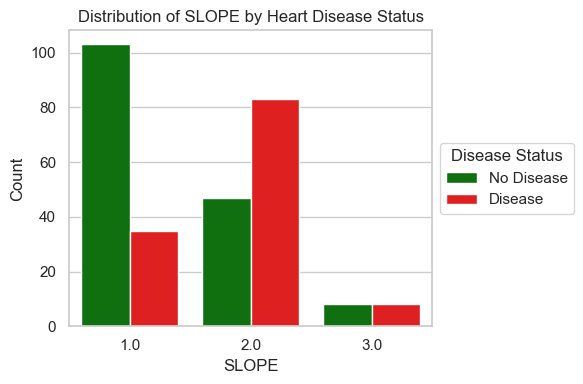

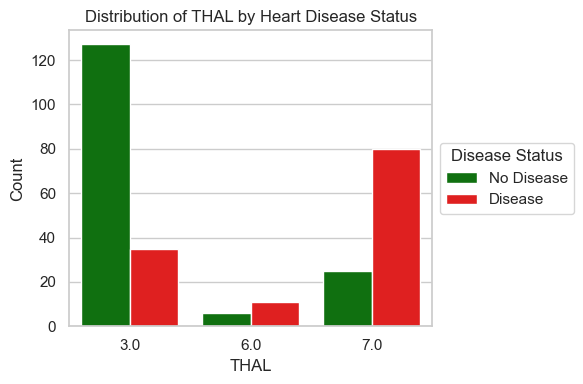

In [94]:
df['disease_str'] = df['has_disease'].map({0: 'No Disease', 1: 'Disease'})

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x=col,hue='disease_str',data=df,palette= colors,hue_order=['No Disease', 'Disease'])
    plt.title(f'Distribution of {col.upper()} by Heart Disease Status')
    plt.xlabel(col.upper())
    plt.ylabel('Count')
    plt.legend(title='Disease Status', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

These bar plots visualize how different categorical features are distributed across patients with and without heart disease:
- **Sex (SEX)**: 
  - Most patients are male (1.0), but heart disease is significantly more prevalent among men
  - Among women (0.0), a majority do not have heart disease
- **Chest Pain Type (CP)**: 
  - Chest pain type 4.0 (asymptomatic) is highly associated with heart disease.
  - Lower CP values (especially `3.0`, which may indicate typical angina) are more common among patients without disease
  - This feature appears to be a strong indicator of disease status.
- **Fasting Blood Sugar (FBS)**: 
  - Most patients fall under 0.0 (normal fasting blood sugar), and within this group, both disease and no-disease patients are common.
  - Small differences between groups, suggesting it is not highly correlated.
- **Resting ECG Results (RESTECG)**: 
  - Category 2.0 is more common among those with heart disease.
  - Category 0.0 (normal) is more common among those without disease.
  - This feature shows some signal but with overlapping distributions.
- **Exercise-Induced Angina (EXANG)**: 
  - Patients with 1.0 (yes for angina) are more likely to have heart disease.
  - Patients with 0.0 (no angina) are mostly in the no-disease group.
  - Supports the idea that angina is a strong risk factor.
- **Slope of ST Segment (SLOPE)**: 
  - A flat slope (2.0) is strongly associated with heart disease.
  - An upsloping ST segment (1.0) is more common in patients without disease.
- **Thalassemia (THAL)**: 
  - Value 3.0 (normal) is mostly associated with no disease.
  - Value 7.0 (likely fixed defect) is highly associated with heart disease.
  - This makes thalassemia one of the most visually predictive categorical features.
The most predictive categorical features seem to be **chest pain type (CP)**, **slope**, **exang**, and **thal**, all showing strong separation between disease and no-disease groups. Features like **sex** and **restecg** offer some useful information, while **fbs** shows weaker differentiation.

### Categorical Feature Encoding and Frequency Analysis

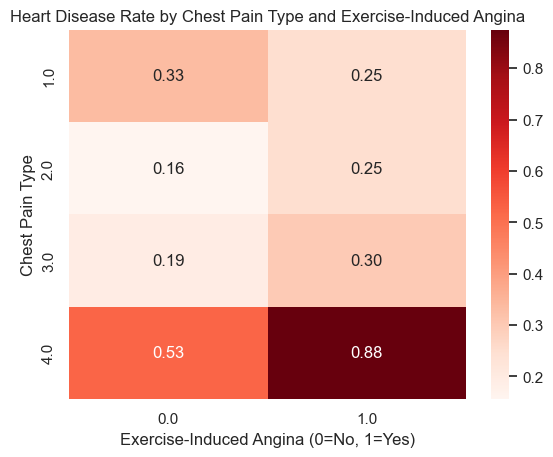

In [98]:
combo = df.groupby(['cp', 'exang'])['has_disease'].mean().unstack()
sns.heatmap(combo, annot=True, cmap='Reds', fmt='.2f')
plt.title('Heart Disease Rate by Chest Pain Type and Exercise-Induced Angina')
plt.xlabel('Exercise-Induced Angina (0=No, 1=Yes)')
plt.ylabel('Chest Pain Type')
plt.show()

Asymptomatic chest pain (CP=4) is much more predictive when combined with exercise-induced angina (EXANG=1). Their interaction is stronger than either feature alone.
- High risk: CP=4.0 (asymptomatic) + EXANG=1.0 → 88% disease rate
- Lower risk: CP=1.0–3.0 (angina types) regardless of EXANG → 16%–33%

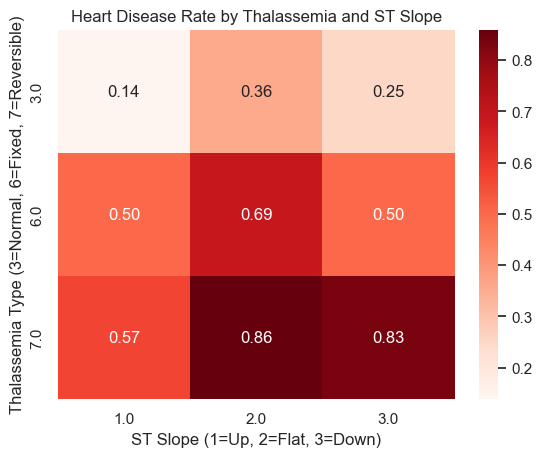

In [101]:
combo = df.groupby(['thal', 'slope'])['has_disease'].mean().unstack()
sns.heatmap(combo, annot=True, cmap='Reds', fmt='.2f')
plt.title('Heart Disease Rate by Thalassemia and ST Slope')
plt.xlabel('ST Slope (1=Up, 2=Flat, 3=Down)')
plt.ylabel('Thalassemia Type (3=Normal, 6=Fixed, 7=Reversible)')
plt.show()

The presence of a reversible defect becomes significantly more concerning when paired with a flat ST slope. These two features interact strongly in predicting heart disease.
- High risk: THAL=7.0 (reversible defect) + SLOPE=2.0 (flat) → 86%
- Low risk: THAL=3.0 (normal) + SLOPE=1.0 (upsloping) → 14%

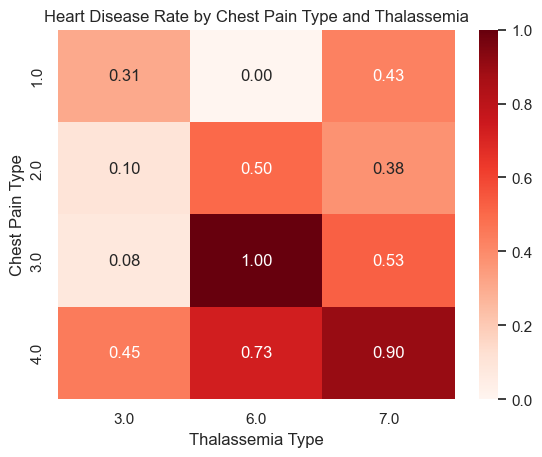

In [104]:
combo = df.groupby(['cp', 'thal'])['has_disease'].mean().unstack()
sns.heatmap(combo, annot=True, cmap='Reds', fmt='.2f')
plt.title('Heart Disease Rate by Chest Pain Type and Thalassemia')
plt.xlabel('Thalassemia Type')
plt.ylabel('Chest Pain Type')
plt.show()

Even though CP=4 (asymptomatic) is usually high risk, some CP=3 (non-anginal pain) + THAL=6.0 combinations are even worse. Together, they form a sharper predictor.
- Highest risk: CP=3.0 + THAL=6.0 → 100%
- Moderate risk: CP=4.0 + THAL=7.0 → 90%
- Lowest risk: CP=1.0 + THAL=6.0 → 0%

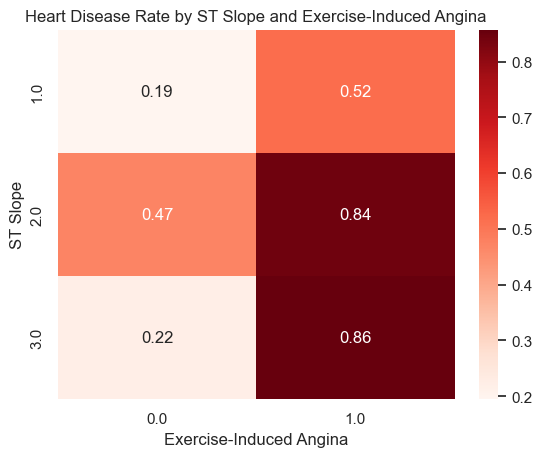

In [107]:
combo = df.groupby(['slope', 'exang'])['has_disease'].mean().unstack()
sns.heatmap(combo, annot=True, cmap='Reds', fmt='.2f')
plt.title('Heart Disease Rate by ST Slope and Exercise-Induced Angina')
plt.xlabel('Exercise-Induced Angina')
plt.ylabel('ST Slope')
plt.show()

The most dangerous combo is a flat or downsloping ST segment plus angina. These two features jointly identify very high-risk patients.
- High risk: SLOPE=2.0 (flat) or 3.0 (down) + EXANG=1.0 → ~84%–86%
- Low risk: SLOPE=1.0 (upsloping) + EXANG=0.0 → 19%

These heatmaps show that certain combinations of clinical features sharply increase the likelihood of heart disease, beyond what each feature indicates on its own. In other words, heart disease risk doesn’t just depend on individual symptoms, but on how those symptoms appear together.
For example:
- Asymptomatic chest pain combined with exercise-induced angina points to hidden but serious risk.
- A reversible thalassemia defect becomes more dangerous when the ST slope is flat, suggesting potential underlying heart stress.
- Some features only reveal their predictive power in combination (like thalassemia and chest pain type), which means we need to look at patient profiles holistically—not just in parts.

---
## 6. Custom Risk Classification Based on Feature Interactions
This section explores whether we can manually classify patients into heart disease risk groups using specific combinations of features. Instead of using machine learning, we define threshold-based rules based on medical reasoning (e.g., high cholesterol or low heart rate).

This approach tests whether logical combinations of key features can separate patients into meaningful low-, medium-, and high-risk categories.

**Manual Risk Classifier #1: Cholesterol + Age**
- Analysis of interactions between cholesterol and age, categorizing patients into risk groups based on combined feature thresholds

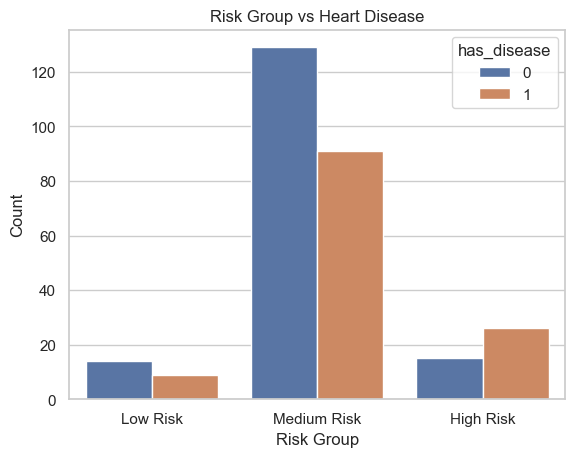

In [113]:
def cholesterol_age_risk(row):
    if row['chol'] > 240 and row['age'] > 60:
        return 'High Risk'
    elif row['chol'] > 200 or row['age'] > 50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['chol_age_risk'] = df.apply(cholesterol_age_risk, axis=1)

sns.countplot(x='chol_age_risk', hue='has_disease', data=df, order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Risk Group vs Heart Disease')
plt.xlabel('Risk Group')
plt.ylabel('Count')
plt.show()

This barplot shows the distribution of heart disease presence across three risk groups based on combined age and cholesterol thresholds:
- Low Risk Group: Most patients do not have heart disease, as expected. This confirms the group definition is effective at identifying lower-risk individuals.
- Medium Risk Group: A significant number of patients with and without heart disease fall into this category, showing it's a more ambiguous group where risk is elevated but not definitive.
- High Risk Group: Although smaller in total count, there is a higher proportion of patients with heart disease compared to those without. This shows that high cholesterol and higher age combined are strong indicators of heart disease risk.

**Manual Risk Classifier #2: Chol + Trestbps + Age + Thalach**
- Creating simple rules-based risk categories based on clear thresholds to classify patients.

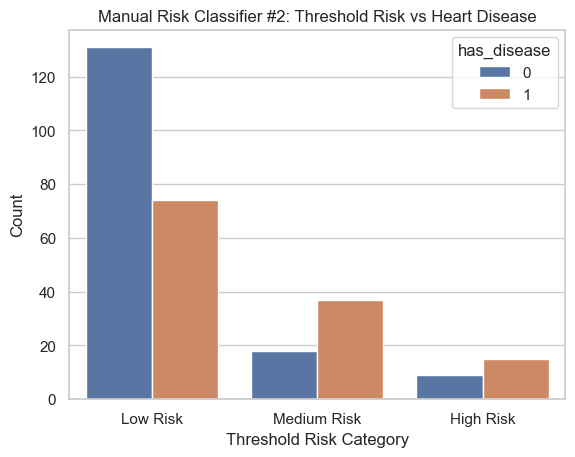

In [117]:
def risk_classifier(row):
    risks = 0
    risks += row['chol'] > 240
    risks += row['trestbps'] > 140
    risks += row['age'] > 60
    risks += row['thalach'] < 120

    if risks >= 3:
        return 'High Risk'
    elif risks == 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['threshold_risk'] = df.apply(risk_classifier, axis=1)

sns.countplot(x='threshold_risk', hue='has_disease', data=df, order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Manual Risk Classifier #2: Threshold Risk vs Heart Disease')
plt.xlabel('Threshold Risk Category')
plt.ylabel('Count')
plt.show()

This classifier expands the previous rule set by incorporating four features instead of two. It adds systolic blood pressure (trestbps) and maximum heart rate (thalach) to the existing age and cholesterol criteria, which allows for more nuanced patient categorization.
**Results:**
- The Low Risk group has a large number of patients, most of whom do not have heart disease, showing that the classifier is effective at capturing people who are likely healthy.
- The Medium Risk group includes a mix of patients with and without disease, similar to Classifier #1, but the counts are more balanced.
- The High Risk group, although smaller, shows a high ratio of heart disease presence. This supports the idea that when three or more of these clinical thresholds are exceeded, the likelihood of disease is very high.

---
## 7. Rule-Based Risk Prediction Accuracy

Was the predicition correct?

risk_prediction_match
Correct      146
Incorrect     83
Uncertain     55
Name: count, dtype: int64


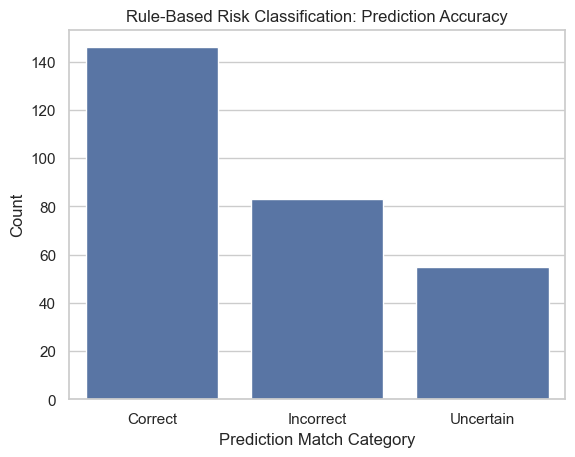

In [122]:
def risk_prediction_match(row):
    if row['threshold_risk'] == 'High Risk' and row['has_disease'] == 1:
        return 'Correct'
    elif row['threshold_risk'] == 'Low Risk' and row['has_disease'] == 0:
        return 'Correct'
    elif row['threshold_risk'] == 'Medium Risk':
        return 'Uncertain'
    else:
        return 'Incorrect'

df['risk_prediction_match'] = df.apply(risk_prediction_match, axis=1)

match_counts = df['risk_prediction_match'].value_counts()
print(match_counts)

sns.countplot(x='risk_prediction_match', data=df, order=['Correct', 'Incorrect', 'Uncertain'])
plt.title('Rule-Based Risk Classification: Prediction Accuracy')
plt.xlabel('Prediction Match Category')
plt.ylabel('Count')
plt.show()

**Interpretation**
- The classifier correctly classified 146 patients, which is a promising signal for a simple threshold-based model.
- There are 83 incorrect predictions, suggesting that while the model works well on clear-cut cases, it can fail on edge cases or those in between.
- The 55 uncertain cases (Medium Risk) reinforce that some patients fall into a gray area. This group would likely benefit from a more nuanced probabilistic model or further diagnostic data.

---
## 8. Feature Correlation Analysis
To better understand the physiological relationships between heart-related metrics, we explore how numeric features interact. While individual variables provide some insight, examining how they move together may reveal underlying patterns relevant to diagnosis or risk modeling. 

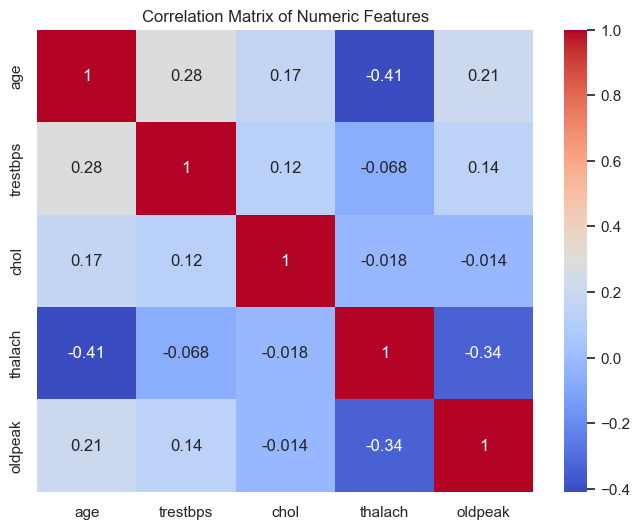

In [126]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

This heatmap shows how strongly each numeric feature is linearly related to the others:
- Age and Thalach: There is a moderate negative correlation (-0.41), meaning older patients tend to have lower maximum heart rates (expected)
- Thalach and Oldpeak: Negatively correlated (-0.34), suggesting that patients with higher maximum heart rates tend to have less ST depression
- Age and Trestbps: A weak positive correlation (0.28), showing that blood pressure tends to rise slightly with age

While some expected clinical patterns appear, the low correlation values suggest that these features capture different aspects of heart health

---

## 9. Additional Dataset Loading and Comparison (VA, Hungary, Switzerland)

**Load all four data sets**

In [131]:
cleveland = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')
va = pd.read_csv('processed.va.data', names=columns, na_values='?')
hungary = pd.read_csv('processed.hungarian.data', names=columns, na_values='?')
switzerland = pd.read_csv('processed.switzerland.data', names=columns, na_values='?')

**Label datasets**

In [134]:
cleveland['location'] = 'cleveland'
va['location'] = 'va'
hungary['location'] = 'hungary'
switzerland['location'] = 'switzerland'

**Combine them**

In [137]:
combined = pd.concat([cleveland, va, hungary, switzerland], ignore_index=True)

**Clean missing values and add binary disease columns**

In [144]:
combined['ca'] = pd.to_numeric(combined['ca'], errors='coerce')
combined['thal'] = pd.to_numeric(combined['thal'], errors='coerce')
combined.loc[:, 'ca'] = combined['ca'].fillna(combined['ca'].median())
combined.loc[:, 'thal'] = combined['thal'].fillna(combined['thal'].mode()[0])
combined['has_disease'] = (combined['target'] > 0).astype(int)

**Cleveland-only subset for comparison**

In [148]:
df_clev = combined[combined['location'] == 'cleveland'].copy()

**Feature means by location and heart disease status**

In [151]:
features = ['age', 'thalach', 'oldpeak', 'chol']
combined.groupby(['location', 'has_disease'])[features].mean().round(1)

age  thalach  oldpeak   chol
location    has_disease                               
cleveland   0            52.6    158.4      0.6  242.6
            1            56.6    139.3      1.6  251.5
hungary     0            46.9    145.0      0.2  240.0
            1            49.5    128.8      1.2  269.2
switzerland 0            54.6    136.6      0.5    0.0
            1            55.4    120.5      0.7    0.0
va          0            56.8    124.9      0.7  175.1
            1            60.2    122.2      1.5  180.0

Key Takeaways:

- **Age** was consistently higher among patients with heart disease across all locations, with the VA dataset showing the oldest overall population.
- **Maximum heart rate (thalach)** was consistently lower in patients with heart disease, aligning with known clinical patterns.
- **ST depression (oldpeak)** showed large differences between disease groups, especially in Hungary and VA, confirming its predictive importance.
- **Cholesterol (chol)** values were generally higher among patients with heart disease, though the Switzerland dataset appears to have missing or invalid cholesterol values (all reported as 0).

These regional comparisons reinforce prior findings on predictive features and raise awareness of dataset inconsistencies that could impact model training and interpretation.

**Visual Summary**

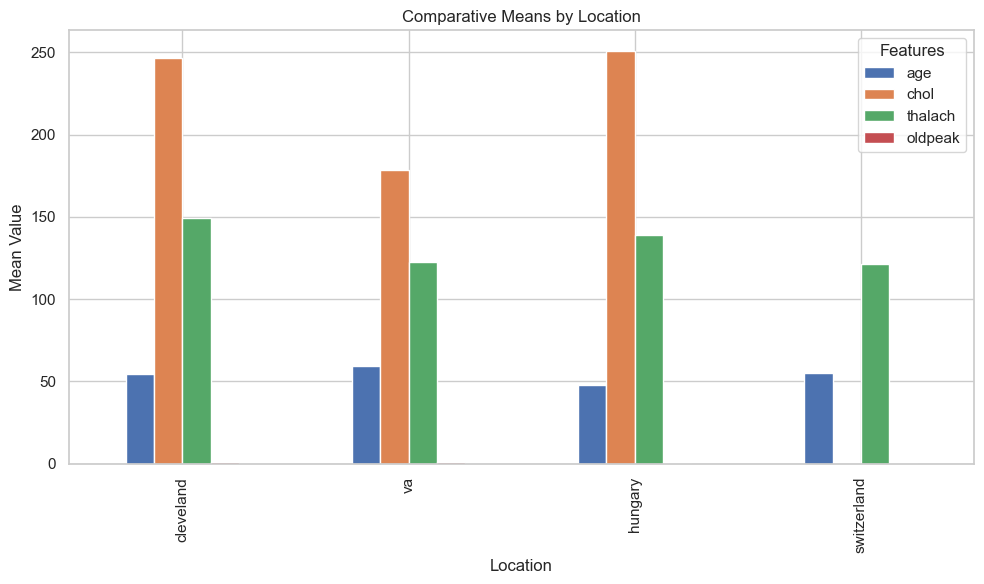

In [155]:
locations = ['cleveland', 'va', 'hungary', 'switzerland']
summary_dict = {}

for loc in locations:
    loc_df = combined[combined['location'] == loc]
    mean_vals = loc_df[['age', 'chol', 'thalach', 'oldpeak']].mean()
    summary_dict[loc] = mean_vals

summary_df = pd.DataFrame(summary_dict)

summary_df.T.plot.bar(figsize=(10,6))
plt.title('Comparative Means by Location')
plt.ylabel('Mean Value')
plt.xlabel('Location')
plt.legend(title='Features')
plt.tight_layout()
plt.show()

**Heart disease rate**

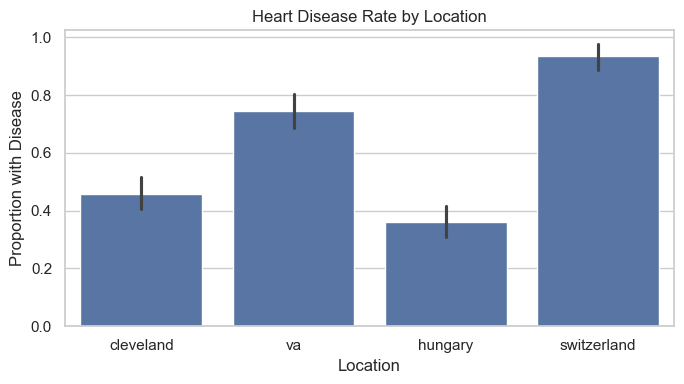

In [158]:
plt.figure(figsize=(7, 4))
sns.barplot(data=combined, x='location', y='has_disease')
plt.title('Heart Disease Rate by Location')
plt.ylabel('Proportion with Disease')
plt.xlabel('Location')
plt.tight_layout()
plt.show()


This barplot shows the proportion of patients with diagnosed heart disease in each regional dataset:
- **Switzerland** shows the highest disease rate (>90%), suggesting a skewed sample possibly focused on high-risk patients.
- **VA patients** also show a high disease rate (~75%), aligning with their older average age and reduced thalach values.
- **Cleveland** reflects a more balanced dataset with moderate disease prevalence (~45%).
- **Hungary** has the lowest disease rate (~35%), potentially due to differing screening criteria or demographics.

These differences are important to recognize when building predictive models, as model performance and generalizability can vary significantly based on population characteristics.

**Age distribution by location**

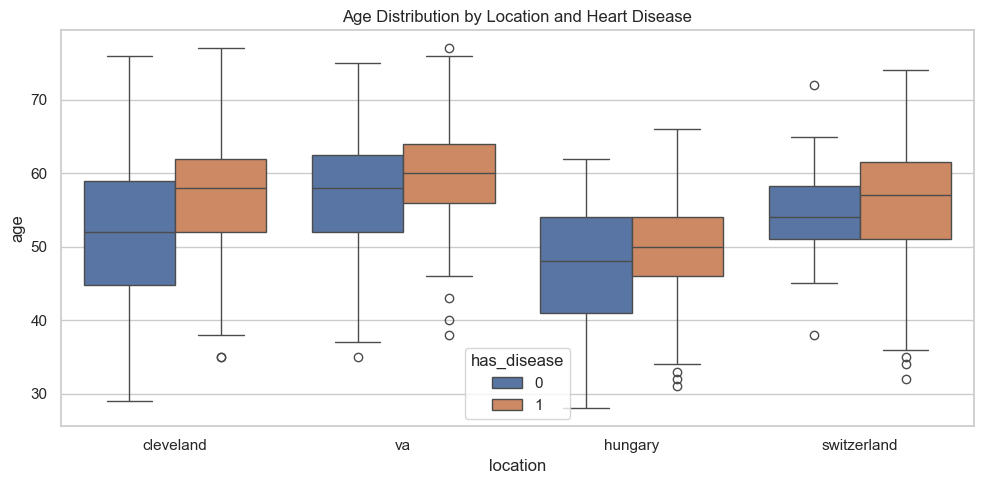

In [162]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=combined, x='location', y='age', hue='has_disease')
plt.title('Age Distribution by Location and Heart Disease')
plt.tight_layout()
plt.show()

This boxplot compares the age distributions across datasets, split by heart disease status:
- In all four locations, patients with heart disease tend to be older than those without.
- **Cleveland and Switzerland** show the broadest age ranges, with clear age-related separation between disease groups.
- **VA patients** are generally older overall, which helps explain their high disease rate.
- **Hungary** includes a much younger population, which aligns with its lower observed disease prevalence.

These patterns reinforce that age is a strong predictor of heart disease.

**Compare thalach and oldpeak distributions across datasets**

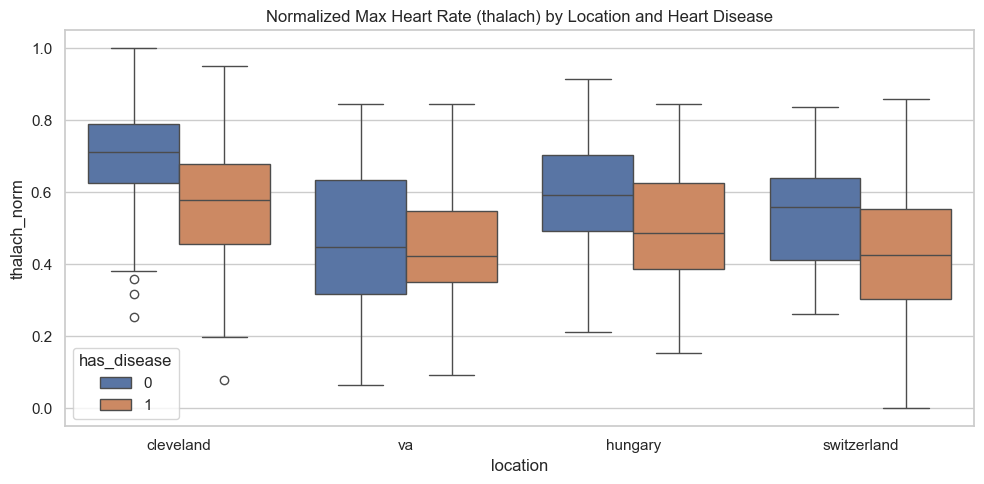

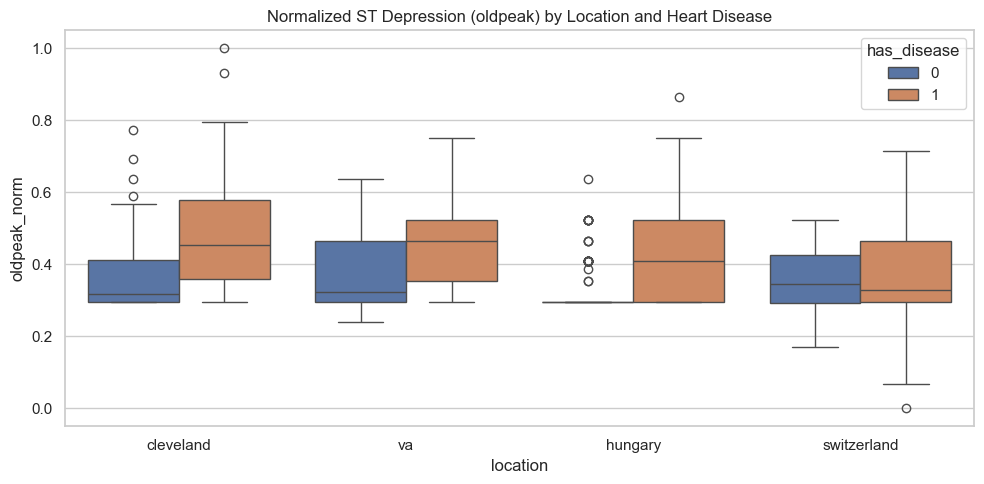

In [166]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=combined, x='location', y='thalach_norm', hue='has_disease')
plt.title('Normalized Max Heart Rate (thalach) by Location and Heart Disease')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=combined, x='location', y='oldpeak_norm', hue='has_disease')
plt.title('Normalized ST Depression (oldpeak) by Location and Heart Disease')
plt.tight_layout()
plt.show()

These boxplots compare the distributions of two key physiological indicators—maximum heart rate (thalach) and ST depression (oldpeak)—across locations and heart disease status.
- **Thalach**: Across all regions, patients with heart disease generally exhibit lower normalized maximum heart rate, with Cleveland and Hungary showing the clearest separation. This supports its reliability as a negative predictor of heart disease, though the effect is less distinct in Switzerland.
- **Oldpeak**: ST depression is typically higher among heart disease patients, especially in Hungary. However, the distributions overlap more than thalach, and the separation is weaker in other regions.

Thalach appears to be a robust predictor across datasets, while oldpeak's predictive value may vary by location. This highlights the importance of validating features across populations when building generalizable models.

---

## 10. Final Summary


In this project, I explored patterns in heart disease data from Cleveland and compared it with other datasets from Virginia (VA), Hungary, and Switzerland. The goal was to understand how certain health indicators relate to heart disease and whether simple rules could help flag high-risk patients.

I started by cleaning the data and checking for missing values and outliers. Then, I used visualizations and statistics to look at how things like age, cholesterol, and heart rate differ between patients with and without heart disease.

A big part of the analysis involved building custom rules to group patients into Low, Medium, or High Risk based on combinations of features. These simple risk models actually did a decent job predicting who had heart disease. I tested two versions — one based on just age and cholesterol, and another that included four features — and found that using more features helped a bit with accuracy.

I also compared patients across different regions. This showed that heart disease rates and health measurements vary a lot depending on location, which is important to keep in mind if we ever wanted to apply this kind of model in the real world.

Overall, this project showed that even basic Python tools and logic can help uncover real patterns in health data. It also highlighted that no single factor tells the whole story — heart disease risk is shaped by multiple things, often interacting with each other.

### Tools, Methods, and Functions Used

**Python & Pandas**
- `pd.read_csv()` – Load datasets
- `.info()`, `.describe()`, `.isnull()` – Inspect data
- `.fillna()` – Fill missing values
- `.groupby()` – Group by categorical variables
- `.apply()` – Apply custom functions row-wise
- `.loc`, `.iloc` – Access rows/columns
- `.round()` – Round numerical results
- `.value_counts()` – Count values in a category
- `.mean()` – Calculate averages
- `.T` – Transpose a DataFrame

**NumPy**
- `np.percentile()` – Used for IQR-based outlier detection
- `np.where()` – Conditional replacement
- `np.logical_and()` – Combine multiple conditions

**Seaborn & Matplotlib (Plotting)**
- `sns.boxplot()` – Visualize distributions by category
- `sns.countplot()` – Compare counts across categories
- `sns.barplot()` – Show average values with error bars
- `sns.heatmap()` – Display correlation matrix
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`, `plt.legend()` – Plot labeling and formatting

**Custom Python Techniques**
- **User-defined functions** – Created custom risk classifiers using thresholds
- **Control flow** – Used `if/elif/else` statements inside functions
- **List comprehension** – Used for data cleaning and masking
- **Boolean masking** – Filter data using conditional logic
- **Data normalization** – Rescaled features for comparison across datasets